<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/EEG_Secondary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Sel instalasi dependensi
%pip -q install "decorator>=4.0.2,<5.0" "mne==1.6.1" "jedi>=0.16" "PyWavelets>=1.4" "h5py>=3.8" "joblib>=1.2" "imbalanced-learn"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.6 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 1 — KONFIGURASI & IMPORT  (UPDATED v6-primary-boost)
# ============================================================
from google.colab import drive
from pathlib import Path
import json, re, warnings, h5py, joblib, mne, pywt, decorator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import ipywidgets as widgets
from math import gcd
from hashlib import sha1
from IPython.display import display, clear_output
from scipy.signal import butter, detrend, resample_poly, sosfiltfilt, welch
from scipy.stats import entropy
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              classification_report, ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")
warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

BASE_DIR               = Path("/content/drive/MyDrive/Creativity-Dataset/")
SECONDARY_DIR          = BASE_DIR / "Secondary"
PRIMARY_RAW_DIR        = BASE_DIR / "Primary-raw"
PRIMARY_MERGED_DIR     = BASE_DIR / "Primary-merged"
PRIMARY_SEGMENTS_CSV   = BASE_DIR / "primary_segments.csv"
CACHE_DIR              = BASE_DIR / "cache"
PREPROCESSED_CACHE_DIR = CACHE_DIR / "preprocessed"
FEATURE_CACHE_DIR      = CACHE_DIR / "features"
OUTPUT_DIR             = BASE_DIR / "output"
for folder in [SECONDARY_DIR, PRIMARY_RAW_DIR, PRIMARY_MERGED_DIR,
               PREPROCESSED_CACHE_DIR, FEATURE_CACHE_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

FS_PRIMARY, FS_SECONDARY, FS_TARGET = 125, 500, 125
BANDPASS_LOW, BANDPASS_HIGH, FILTER_ORDER = 1.0, 40.0, 4

KNOWN_RAIL_ABS_THRESHOLD        = 180000.0
ROBUST_OUTLIER_MAD_MULTIPLIER   = 25.0
MAX_REPAIR_RATIO_PER_CHANNEL    = 0.05
bad_channel_z_threshold         = 5.0
BAD_CHANNEL_Z_THRESHOLD         = bad_channel_z_threshold
EPOCH_ARTIFACT_Z_THRESHOLD      = 5.0

WAVELET               = "db4"
ADD_SPECTRAL_FEATURES = True
MAX_EPOCHS_PER_SUBJECT_CLASS = 300
DEBUG_MAX_SUBJECTS            = 2

CACHE_VERSION          = "v6_primary_boost_plv_dwt_125hz"
FORCE_REBUILD_FEATURES = True
RANDOM_STATE           = 42

# ─── Dataset mode — ubah di sini saja ────────────────────────────────────────
DATASET_MODE       = "secondary"   # ganti ke "secondary" untuk dataset sekunder
PRIMARY_INPUT_MODE = "separate"

# ─── EXPERIMENT_CONFIGS — otomatis disesuaikan per dataset ───────────────────
# Primary (1 subjek, OpenBCI, sinyal lebih noisy):
#   - Overlap tinggi (0.75) untuk memperbanyak epoch
#   - trim lebih kecil (1.0s) agar lebih banyak sinyal terpakai
# Secondary (1 subjek, BrainVision, sinyal bersih):
#   - Pertahankan config 4.0s/0.5 yang terbukti menghasilkan 86%
#   - Tambah 2.0s/0.75 sebagai kandidat tambahan
if DATASET_MODE == "primary":
    EXPERIMENT_CONFIGS = [
        {"epoch_seconds": 2.0, "overlap_ratio": 0.75, "primary_trim_seconds": 1.0},
        {"epoch_seconds": 2.0, "overlap_ratio": 0.5,  "primary_trim_seconds": 2.0},
        {"epoch_seconds": 4.0, "overlap_ratio": 0.75, "primary_trim_seconds": 2.0},
    ]
else:
    # Secondary: pertahankan config yang sudah terbukti 86%
    EXPERIMENT_CONFIGS = [
        {"epoch_seconds": 4.0, "overlap_ratio": 0.5,  "primary_trim_seconds": 2.0},
        {"epoch_seconds": 2.0, "overlap_ratio": 0.75, "primary_trim_seconds": 2.0},
        {"epoch_seconds": 2.0, "overlap_ratio": 0.5,  "primary_trim_seconds": 2.0},
    ]

MANUAL_SELECTED_FILES = []
print("   Environment Ready")
print(f"  CACHE_VERSION   : {CACHE_VERSION}")
print(f"  DATASET_MODE    : {DATASET_MODE}")
print(f"  Target classes  : RST, IDG, IDE, IDR  (4 kelas)")
print(f"  MAX_EPOCHS/class: {MAX_EPOCHS_PER_SUBJECT_CLASS}")
print(f"  Epoch configs   :")
for cfg in EXPERIMENT_CONFIGS:
    print(f"    {cfg['epoch_seconds']}s / overlap {cfg['overlap_ratio']}")

Mounted at /content/drive
   Environment Ready
  CACHE_VERSION   : v6_primary_boost_plv_dwt_125hz
  DATASET_MODE    : secondary
  Target classes  : RST, IDG, IDE, IDR  (4 kelas)
  MAX_EPOCHS/class: 300
  Epoch configs   :
    4.0s / overlap 0.5
    2.0s / overlap 0.75
    2.0s / overlap 0.5


In [3]:
# ============================================================
# CELL 2 — LABEL & KANAL  (UPDATED v4-4class)
# ============================================================

# Label asli di file .mat (untuk parsing nama variable)
LABELS_RAW = ["RST1", "IDG", "IDE", "IDR", "RST2"]

# Target 4 kelas setelah remapping
TARGET_LABELS = ["RST", "IDG", "IDE", "IDR"]

PRIMARY_CHANNELS_ORIGINAL = [
    "Fp1","Fp2","F3","F4","F7","F8","C3","C4",
    "T3","T4","T5","T6","P3","P4","O1","O2"
]
CANONICAL_CHANNELS = [
    "Fp1","Fp2","F3","F4","F7","F8","C3","C4",
    "T7","T8","P7","P8","P3","P4","O1","O2"
]

SECONDARY_CHANNELS_64 = [
    "Fp1","Fp2","Fpz","AF3","AF4","AF7","AF8","AFz",
    "F1","F2","F3","F4","F5","F6","F7","F8","Fz",
    "FT7","FT8","FC1","FC2","FC3","FC4","FC5","FC6","FCz",
    "T7","T8","C1","C2","C3","C4","C5","C6","Cz",
    "TP7","TP8","CP1","CP2","CP3","CP4","CP5","CP6","CPz",
    "P1","P2","P3","P4","P5","P6","P7","P8","P9","P10","Pz",
    "PO3","PO4","PO7","PO8","POz","O1","O2","Oz","Iz"
]
SECONDARY_CHANNELS_63      = [ch for ch in SECONDARY_CHANNELS_64 if ch != "Cz"]
SECONDARY_SELECTED_INDICES = [SECONDARY_CHANNELS_63.index(ch) for ch in CANONICAL_CHANNELS]

def normalize_label(text):
    """Parse nama variable/file → label RAW (RST1/RST2/IDG/IDE/IDR)."""
    text = str(text).upper()
    for label in LABELS_RAW:
        if label in text:
            return label
    return None

def remap_to_4class(raw_label):
    """
    Gabungkan RST1 dan RST2 menjadi satu kelas RST.
    Label lain (IDG, IDE, IDR) tetap.
    Kembalikan None jika label tidak dikenali.
    """
    if raw_label in ("RST1", "RST2"):
        return "RST"
    if raw_label in ("IDG", "IDE", "IDR"):
        return raw_label
    return None

def infer_subject_id(text, prefix):
    match = re.search(r"SUB(?:JECT)?[_\-\s]*(\d+)", str(text), flags=re.IGNORECASE)
    if not match:
        raise ValueError(f"Nomor subjek tidak ditemukan: {text}")
    return f"{prefix}_{int(match.group(1)):03d}"

def stable_name(text):
    return sha1(str(text).encode("utf-8")).hexdigest()[:16]

channel_mapping_df = pd.DataFrame({
    "kanal_primer":      PRIMARY_CHANNELS_ORIGINAL,
    "kanal_harmonisasi": CANONICAL_CHANNELS,
    "idx_sekunder":      SECONDARY_SELECTED_INDICES
})
display(channel_mapping_df)
print("Index 16 kanal sekunder:", SECONDARY_SELECTED_INDICES)
print("Target 4 kelas:", TARGET_LABELS)
print("Mapping RST: RST1 + RST2 → RST")

,kanal_primer,kanal_harmonisasi,idx_sekunder
0,Fp1,Fp1,0
1,Fp2,Fp2,1
2,F3,F3,10
3,F4,F4,11
4,F7,F7,14
5,F8,F8,15
6,C3,C3,30
7,C4,C4,31
8,T3,T7,26
9,T4,T8,27


Index 16 kanal sekunder: [0, 1, 10, 11, 14, 15, 30, 31, 26, 27, 49, 50, 45, 46, 59, 60]
Target 4 kelas: ['RST', 'IDG', 'IDE', 'IDR']
Mapping RST: RST1 + RST2 → RST


In [4]:
import re
from pathlib import Path
import scipy.io as sio
import h5py
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from hashlib import sha1

# --- HELPER FUNCTIONS ---
def load_record_eeg(ref):
    arr = load_mat_variable(ref['file_path'], ref['mat_key'])
    if ref['source'] == 'secondary':
        eeg = arr if arr.shape[0] == 63 else arr.T
        return eeg[SECONDARY_SELECTED_INDICES, :].astype(float), None
    eeg, log = extract_primary_eeg(arr)
    return eeg.astype(float), log

def list_mat_variables(file_path):
    file_path = Path(file_path)
    try: return [(name, tuple(shape), dtype) for name, shape, dtype in sio.whosmat(file_path)]
    except:
        results = []
        with h5py.File(file_path, 'r') as handle:
            def visitor(name, obj):
                if isinstance(obj, h5py.Dataset): results.append((name, tuple(obj.shape), str(obj.dtype)))
            handle.visititems(visitor)
        return results

def load_mat_variable(file_path, key):
    try:
        mat = sio.loadmat(file_path, variable_names=[key])
        return np.asarray(mat[key])
    except:
        with h5py.File(file_path, 'r') as handle: return np.asarray(handle[key])

def extract_primary_eeg(arr):
    arr = np.asarray(arr, dtype=float)
    d = arr if arr.shape[1] in {16, 17} else arr.T
    if d.shape[1] == 17: return d[:, 1:17].T, None
    return d[:, :16].T, None

def detect_file_source(path):
    f = Path(path).resolve()
    if f.is_relative_to(SECONDARY_DIR.resolve()): return 'secondary'
    return 'primary'

def get_all_available_files():
    sec = sorted(SECONDARY_DIR.rglob('*.mat'))
    pri_raw = sorted(PRIMARY_RAW_DIR.rglob('*.mat'))
    pri_merged = sorted(PRIMARY_MERGED_DIR.rglob('*.mat'))
    if DATASET_MODE == 'secondary': return sec
    if DATASET_MODE == 'primary': return pri_merged if PRIMARY_INPUT_MODE == 'merged' else pri_raw
    return sec + pri_merged + pri_raw

def choose_primary_key(file_path):
    vars = list_mat_variables(file_path)
    cands = [(int(np.prod(s)), n) for n, s, _ in vars if len(s) == 2]
    if not cands: raise ValueError(f"No 2D array in {file_path}")
    avail_vars = [n for _, n in cands]
    return "data" if "data" in avail_vars else max(cands, key=lambda x: x[0])[1]

def discover_selected_refs(paths):
    res = []
    for p in paths:
        f = Path(p); src = detect_file_source(f)
        sid = infer_subject_id(f.stem, "SEC" if src == "secondary" else "PRI")
        if src == "secondary":
            vars = list_mat_variables(f)
            for k, s, _ in vars:
                lbl = normalize_label(k)
                if lbl and len(s) == 2 and 63 in s:
                    res.append({"source": "secondary", "subject_id": sid, "record_id": f"{sid}__{k}", "label": lbl, "file_path": str(f), "mat_key": k, "sfreq": FS_SECONDARY})
        else:
            lbl = normalize_label(f.stem)
            if lbl is None:
                print(f"Lewati file primer tanpa label: {f.name}")
                continue
            res.append({"source": "primary", "subject_id": sid, "record_id": f"{sid}__{f.stem}", "label": lbl, "file_path": str(f), "mat_key": choose_primary_key(f), "sfreq": FS_PRIMARY})
    return res

def on_process_clicked(b):
    with output_area:
        clear_output()
        if not file_selector.value: print("Pilih file dulu."); return
        try:
            global refs, refs_df, record_count_df, MANUAL_SELECTED_FILES
            refs = discover_selected_refs(file_selector.value)
            if not refs: raise ValueError("Tidak ada record valid yang ditemukan.")
            refs_df = pd.DataFrame(refs)
            record_count_df = refs_df.groupby(["source", "subject_id", "label"]).size().reset_index(name="count")
            MANUAL_SELECTED_FILES = list(file_selector.value)
            display(record_count_df)
            print(f"Siap: {len(refs)} record terdeteksi.")
        except Exception as e: print(f"Gagal: {e}")

avail_files = get_all_available_files()
opts_data = [(f'[{detect_file_source(f).upper()}] {f.name}', str(f)) for f in avail_files]
file_selector = widgets.SelectMultiple(options=opts_data, layout={'width': '100%', 'height': '200px'})
btn_proc = widgets.Button(description='Proses File Terpilih', button_style='success')
output_area = widgets.Output()
btn_proc.on_click(on_process_clicked)
display(widgets.VBox([widgets.HTML('<b>Pilih file MAT (Ctrl+Klik):</b>'), file_selector, btn_proc, output_area]))

In [5]:
# ============================================================
# PREPROCESSING UTILS & CACHE  (UPDATED v6 — primary signal norm)
# ============================================================
def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0: return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    return 0.6745 * (v - med) / (mad + 1e-12) if mad > 1e-12 else np.zeros_like(v)

def interpolate_invalid_1d(sig, mask):
    return pd.Series(sig).mask(mask).interpolate(limit_direction="both").bfill().ffill().values

def repair_primary_invalid_samples(eeg):
    eeg, logs = eeg.copy(), []
    for i, ch in enumerate(CANONICAL_CHANNELS):
        sig, fin = eeg[i], eeg[i][np.isfinite(eeg[i])]
        if fin.size == 0:
            mask = np.ones_like(sig, dtype=bool)
        else:
            med = np.median(fin)
            mad = np.median(np.abs(fin - med))
            scale = 1.4826 * mad if mad > 1e-12 else (np.std(fin) + 1e-12)
            mask = ~np.isfinite(sig) | (np.abs(sig) >= KNOWN_RAIL_ABS_THRESHOLD)
            mask |= (np.abs(sig - med) > (ROBUST_OUTLIER_MAD_MULTIPLIER * scale))
        if mask.mean() > MAX_REPAIR_RATIO_PER_CHANNEL:
            raise ValueError(f"{ch} too many bad samples")
        if mask.any():
            eeg[i] = interpolate_invalid_1d(sig, mask)
        logs.append({"ch": ch, "count": int(mask.sum()), "ratio": mask.mean()})
    return eeg, logs

def apply_bandpass(eeg, sfreq):
    eeg = detrend(eeg, axis=1, type="linear")
    sos = butter(FILTER_ORDER, [BANDPASS_LOW, BANDPASS_HIGH],
                 btype="bandpass", fs=sfreq, output="sos")
    return sosfiltfilt(sos, eeg, axis=1)

def detect_bad_channels(eeg):
    std = np.std(eeg, axis=1)
    return (std < 1e-10) | (np.abs(robust_zscore(np.log10(std + 1e-12))) > BAD_CHANNEL_Z_THRESHOLD)

def interpolate_bad_channels(eeg, sfreq, mask):
    bads = [ch for ch, is_bad in zip(CANONICAL_CHANNELS, mask) if is_bad]
    if not bads: return eeg, []
    if len(bads) > 6:
        raise ValueError(f"Too many bad channels ({len(bads)}): {bads}")
    raw = mne.io.RawArray(eeg, mne.create_info(CANONICAL_CHANNELS, sfreq, "eeg"), verbose=0)
    raw.set_montage("standard_1020", on_missing="ignore")
    raw.info["bads"] = bads
    return raw.interpolate_bads(reset_bads=True, verbose=0).get_data(), bads

def normalize_primary_channels(eeg):
    """
    Robust Z-score normalisasi per-channel untuk sinyal primer OpenBCI.
    Tujuan: menyamakan skala amplitudo antar channel yang berbeda impedansi,
    sehingga fitur DWT/Hjorth tidak didominasi channel dengan amplitudo besar.

    Hanya diaplikasikan ke primary karena secondary sudah dinormalisasi
    oleh pipeline HAPPE (re-reference ke average sudah menstabilkan skala).
    """
    eeg = eeg.copy().astype(float)
    for i in range(eeg.shape[0]):
        sig = eeg[i]
        med = np.median(sig)
        mad = np.median(np.abs(sig - med))
        scale = 1.4826 * mad if mad > 1e-12 else (np.std(sig) + 1e-12)
        eeg[i] = (sig - med) / scale
    return eeg.astype(np.float32)

def preprocess_record(ref):
    eeg, c_log = load_record_eeg(ref)
    rep_log, bads = None, []

    if ref["source"] == "primary":
        eeg, rep_log = repair_primary_invalid_samples(eeg)

    eeg = apply_bandpass(eeg, ref["sfreq"])

    if ref["source"] == "primary":
        eeg, bads = interpolate_bad_channels(
            eeg, ref["sfreq"], detect_bad_channels(eeg)
        )

    # Average re-reference
    eeg = eeg - np.mean(eeg, axis=0, keepdims=True)

    # UPDATE v6: Robust Z-score normalisasi per-channel KHUSUS primary
    # Dilakukan setelah rereferencing agar baseline sudah stabil
    if ref["source"] == "primary":
        eeg = normalize_primary_channels(eeg)

    if int(ref["sfreq"]) != FS_TARGET:
        eeg = resample_poly(
            eeg,
            FS_TARGET // gcd(int(ref["sfreq"]), FS_TARGET),
            int(ref["sfreq"]) // gcd(int(ref["sfreq"]), FS_TARGET),
            axis=1
        )
    return eeg.astype(np.float32), {
        "counter": c_log, "repair": rep_log, "bad_channels": bads
    }

def preprocessed_cache_path(ref):
    stamp = (f"{Path(ref['file_path']).stat().st_size}__"
             f"{Path(ref['file_path']).stat().st_mtime_ns}")
    ident = (f"{CACHE_VERSION}__{ref['record_id']}__{stamp}__"
             f"{ref.get('start_sec','')}__{ref.get('end_sec','')}")
    return PREPROCESSED_CACHE_DIR / f"{stable_name(ident)}.npy"

def prepare_preprocessed_cache(refs):
    rows = []
    for i, ref in enumerate(refs, 1):
        path = preprocessed_cache_path(ref)
        print(f"[{i:03d}/{len(refs):03d}] {ref['record_id']}")
        if path.exists():
            eeg, log = np.load(path, mmap_mode="r"), {"cached": True}
        else:
            eeg, log = preprocess_record(ref)
            np.save(path, eeg)
        rows.append({
            **ref,
            "cache_path":      str(path),
            "n_samples":       eeg.shape[1],
            "duration":        eeg.shape[1] / FS_TARGET,
            "preprocess_log":  json.dumps(log, default=str)
        })
    return pd.DataFrame(rows)

In [6]:
# ============================================================
# CELL 5 — EPOCHING & FEATURE EXTRACTION  (UPDATED v4-4class)
# ============================================================

def epoch_starts(n, sec, overlap, trim):
    sz   = int(sec * FS_TARGET)
    step = int(sz * (1 - overlap))
    t_sz = int(trim * FS_TARGET)
    if step <= 0:
        raise ValueError("Invalid overlap")
    if (n - 2 * t_sz) >= sz:
        return list(range(t_sz, n - t_sz - sz + 1, step)), sz
    return [], sz

def screen_epoch_starts(eeg, starts, sz):
    if not starts:
        return []
    eps  = np.stack([eeg[:, s:s + sz] for s in starts])
    ptp  = np.max(np.ptp(eps, axis=2), axis=1)
    grad = np.max(np.mean(np.abs(np.diff(eps, axis=2)), axis=2), axis=1)
    mask = (
        (np.abs(robust_zscore(np.log10(ptp  + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD) &
        (np.abs(robust_zscore(np.log10(grad + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
    )
    return [s for s, k in zip(starts, mask) if k]

def hjorth_parameters(sig):
    sig = np.asarray(sig, dtype=float)
    act = np.var(sig)
    if act <= 1e-18:
        return 0.0, 0.0, 0.0
    d1, d2 = np.diff(sig), np.diff(sig, n=2)
    v1, v2 = np.var(d1), np.var(d2)
    mob = np.sqrt(v1 / act)
    com = (np.sqrt(v2 / v1) / mob) if (v1 > 1e-18 and mob > 1e-18) else 0.0
    return float(act), float(mob), float(com)

FREQUENCY_BANDS = {
    "delta": (1,  4),
    "theta": (4,  8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}

def adaptive_dwt_level(n_samples):
    """
    Level DWT maksimum yang aman sehingga koefisien terpendek (A_level)
    punya panjang >= MIN_COEFF_LEN (16 sample).
    Di-cap ke 5 agar nama kolom konsisten.

    Contoh:
      epoch 2s @ 125 Hz → 250 sample → level aman = 3  (A3 ~ 31 sample)
      epoch 4s @ 125 Hz → 500 sample → level aman = 5  (A5 ~ 15 sample, pas batas)
    """
    MIN_COEFF_LEN = 16
    level  = 0
    length = n_samples
    while length // 2 >= MIN_COEFF_LEN and level < 5:
        length = length // 2
        level += 1
    return max(level, 1)

def extract_features(epoch):
    """
    epoch : ndarray (n_channels, n_samples)
    Return : list float, panjang <= len(ALL_FEATURE_COLUMNS)
             (zero-padded di build_feature_table jika level DWT < 5)
    """
    n_samples = epoch.shape[1]
    level     = adaptive_dwt_level(n_samples)

    feats = []
    for sig in epoch:
        coeffs = pywt.wavedec(sig, WAVELET, level=level)
        for c in coeffs:
            feats.extend(hjorth_parameters(c))

    if ADD_SPECTRAL_FEATURES:
        nperseg = min(n_samples, 2 * FS_TARGET)
        for sig in epoch:
            f_arr, psd = welch(sig, fs=FS_TARGET, nperseg=nperseg)
            mask  = (f_arr >= 1.0) & (f_arr < 40.0)
            total = np.trapz(psd[mask], f_arr[mask]) + 1e-12
            for b_l, b_h in FREQUENCY_BANDS.values():
                bm = (f_arr >= b_l) & (f_arr < b_h)
                feats.append(float(np.trapz(psd[bm], f_arr[bm]) / total))
            feats.append(float(entropy(psd / (psd.sum() + 1e-12) + 1e-12, base=2)))

    return feats

# ─── Nama kolom (berdasarkan level-5 maksimum) ───────────────────────────────
DWT_COEFFS_NAMES = ["A5", "D5", "D4", "D3", "D2", "D1"]
DWT_COLS  = [
    f"{ch}__{cf}__{p}"
    for ch in CANONICAL_CHANNELS
    for cf in DWT_COEFFS_NAMES
    for p in ["activity", "mobility", "complexity"]
]
SPEC_COLS = [
    f"{ch}__spectral__{p}"
    for ch in CANONICAL_CHANNELS
    for p in [*FREQUENCY_BANDS.keys(), "entropy"]
]
ALL_FEATURE_COLUMNS = DWT_COLS + (SPEC_COLS if ADD_SPECTRAL_FEATURES else [])

print(f"Kolom fitur maksimum (level-5): {len(ALL_FEATURE_COLUMNS)}")
print(f"  DWT  : {len(DWT_COLS)}  |  Spectral: {len(SPEC_COLS)}")

Kolom fitur maksimum (level-5): 384
  DWT  : 288  |  Spectral: 96


In [7]:
from scipy.signal import hilbert

if 'bad_channel_z_threshold' in globals():
    BAD_CHANNEL_Z_THRESHOLD = bad_channel_z_threshold

# ─── Pasangan channel untuk PLV connectivity ──────────────────────────────────
CONNECTIVITY_PAIRS = (
    [("F3","F4"), ("F7","F8"), ("Fp1","Fp2")]          # frontal inter-hemispheric
    + [("F3","P3"), ("F4","P4"), ("F7","P7"), ("F8","P8")]  # frontal-parietal ipsilateral
    + [("F3","O1"), ("F4","O2")]                        # frontal-occipital
    + [("T7","T8"), ("P7","P8")]                        # temporal inter-hemispheric
    + [("C3","P3"), ("C4","P4"), ("C3","C4")]           # central-parietal
)
CONNECTIVITY_BANDS = {"alpha": (8,13), "theta": (4,8), "beta": (13,30)}

CONNECTIVITY_COLS = [
    f"plv__{ch1}_{ch2}__{band}"
    for ch1, ch2 in CONNECTIVITY_PAIRS
    for band in CONNECTIVITY_BANDS
]

def compute_plv_band(sig1, sig2, flo, fhi):
    """PLV antara sig1 dan sig2 pada band [flo, fhi] Hz. Return float 0..1."""
    sos  = butter(4, [flo, fhi], btype="bandpass", fs=FS_TARGET, output="sos")
    s1   = sosfiltfilt(sos, sig1.astype(float))
    s2   = sosfiltfilt(sos, sig2.astype(float))
    phi1 = np.angle(hilbert(s1))
    phi2 = np.angle(hilbert(s2))
    return float(np.abs(np.mean(np.exp(1j * (phi1 - phi2)))))

def extract_connectivity_features(epoch):
    """
    Ekstrak PLV antar pasangan channel untuk band alpha, theta, beta.
    epoch : ndarray (n_channels, n_samples)
    Return: list float, panjang = len(CONNECTIVITY_PAIRS) * len(CONNECTIVITY_BANDS)
    """
    ch_idx = {ch: i for i, ch in enumerate(CANONICAL_CHANNELS)}
    feats  = []
    for ch1, ch2 in CONNECTIVITY_PAIRS:
        if ch1 not in ch_idx or ch2 not in ch_idx:
            feats.extend([0.0] * len(CONNECTIVITY_BANDS))
            continue
        s1, s2 = epoch[ch_idx[ch1]], epoch[ch_idx[ch2]]
        for flo, fhi in CONNECTIVITY_BANDS.values():
            feats.append(compute_plv_band(s1, s2, flo, fhi))
    return feats

def config_id(cfg):
    return (f"epoch_{cfg['epoch_seconds']}s"
            f"__overlap_{cfg['overlap_ratio']}"
            f"__trim_{cfg['primary_trim_seconds']}s"
            f"__spectral_{ADD_SPECTRAL_FEATURES}"
            f"__4class__{CACHE_VERSION}")

def prepared_fingerprint(recs):
    return stable_name("|".join(sorted(recs["cache_path"].astype(str))))

def feature_cache_path(cfg, recs):
    key = f"{DATASET_MODE}__{config_id(cfg)}__{prepared_fingerprint(recs)}"
    return FEATURE_CACHE_DIR / f"{stable_name(key)}.pkl"

def build_feature_table(prepared_records, config):
    """
    Buat tabel fitur dengan:
    - Remapping RST1+RST2 → RST  (4 kelas target)
    - DWT adaptif + PLV connectivity dengan zero-padding
    """
    descriptors = []
    for _, record in prepared_records.iterrows():
        eeg       = np.load(record["cache_path"], mmap_mode="r")
        trim      = (config["primary_trim_seconds"]
                     if record["source"] == "primary" else 0.0)
        starts, size = epoch_starts(
            record["n_samples"], config["epoch_seconds"],
            config["overlap_ratio"], trim
        )
        raw_label    = record["label"]
        target_label = remap_to_4class(raw_label)
        if target_label is None:
            continue

        for s in screen_epoch_starts(eeg, starts, size):
            descriptors.append({
                "source":      record["source"],
                "subject_id":  record["subject_id"],
                "group_id":    f"{record['source']}__{record['subject_id']}",
                "record_id":   record["record_id"],
                "label":       target_label,
                "raw_label":   raw_label,
                "cache_path":  record["cache_path"],
                "epoch_start": int(s),
                "epoch_size":  int(size),
            })

    if not descriptors:
        raise ValueError("Tidak ada epoch. Periksa label dan konfigurasi.")

    desc_df = pd.DataFrame(descriptors)

    df = pd.concat([
        g.sample(n=min(len(g), MAX_EPOCHS_PER_SUBJECT_CLASS), random_state=RANDOM_STATE)
        for _, g in desc_df.groupby(["source", "subject_id", "label"], sort=False)
    ], ignore_index=True)

    print(f"Epochs setelah balancing: {len(df)}")
    display(df.groupby(["source", "label"]).size().reset_index(name="epochs"))

    # ── Ekstraksi: DWT-Hjorth + Spectral + PLV ────────────────────────
    n_max      = len(ALL_FEATURE_COLUMNS)
    all_cols   = ALL_FEATURE_COLUMNS + CONNECTIVITY_COLS
    rows = []
    for path, group in df.groupby("cache_path", sort=False):
        eeg = np.load(path, mmap_mode="r")
        for _, d in group.iterrows():
            ep = np.array(
                eeg[:, int(d["epoch_start"]):int(d["epoch_start"]) + int(d["epoch_size"])]
            )
            # DWT + Spectral
            raw_feats = extract_features(ep)
            if len(raw_feats) < n_max:
                raw_feats = raw_feats + [0.0] * (n_max - len(raw_feats))
            elif len(raw_feats) > n_max:
                raw_feats = raw_feats[:n_max]

            # PLV connectivity
            plv_feats = extract_connectivity_features(ep)

            all_feats = raw_feats + plv_feats

            rows.append({
                **d.drop("cache_path").to_dict(),
                **dict(zip(all_cols, all_feats))
            })

    return pd.DataFrame(rows)

# ─── Pastikan preprocessing cache siap ───────────────────────────────────────
prepared_records = prepare_preprocessed_cache(refs)

# ─── Build / load feature tables ─────────────────────────────────────────────
feature_tables = {}
for config in EXPERIMENT_CONFIGS:
    ident = config_id(config)
    cpath = feature_cache_path(config, prepared_records)
    print(f"\n{'='*50}\nCONFIG: {ident}\n{'='*50}")
    if cpath.exists() and not FORCE_REBUILD_FEATURES:
        f_df = pd.read_pickle(cpath)
        print(f"[CACHE] Loaded {len(f_df)} epochs")
    else:
        f_df = build_feature_table(prepared_records, config)
        f_df.to_pickle(cpath)
    feature_tables[ident] = f_df
    display(f_df.groupby(["source", "label"]).size().reset_index(name="epochs"))

[001/011] SEC_010__Creativity_10_1_IDE
[002/011] SEC_010__Creativity_10_1_IDG
[003/011] SEC_010__Creativity_10_1_IDR
[004/011] SEC_010__Creativity_10_2_IDE
[005/011] SEC_010__Creativity_10_2_IDG
[006/011] SEC_010__Creativity_10_2_IDR
[007/011] SEC_010__Creativity_10_3_IDE
[008/011] SEC_010__Creativity_10_3_IDG
[009/011] SEC_010__Creativity_10_3_IDR
[010/011] SEC_010__Creativity_10_RST1
[011/011] SEC_010__Creativity_10_RST2

CONFIG: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__4class__v6_primary_boost_plv_dwt_125hz
Epochs setelah balancing: 349


,source,label,epochs
0,secondary,IDE,86
1,secondary,IDG,108
2,secondary,IDR,8
3,secondary,RST,147


,source,label,epochs
0,secondary,IDE,86
1,secondary,IDG,108
2,secondary,IDR,8
3,secondary,RST,147



CONFIG: epoch_2.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v6_primary_boost_plv_dwt_125hz
Epochs setelah balancing: 934


,source,label,epochs
0,secondary,IDE,300
1,secondary,IDG,300
2,secondary,IDR,34
3,secondary,RST,300


,source,label,epochs
0,secondary,IDE,300
1,secondary,IDG,300
2,secondary,IDR,34
3,secondary,RST,300



CONFIG: epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__4class__v6_primary_boost_plv_dwt_125hz
Epochs setelah balancing: 709


,source,label,epochs
0,secondary,IDE,175
1,secondary,IDG,219
2,secondary,IDR,19
3,secondary,RST,296


,source,label,epochs
0,secondary,IDE,175
1,secondary,IDG,219
2,secondary,IDR,19
3,secondary,RST,296


In [8]:
# ============================================================
# DERIVED FEATURES & ENSEMBLE BUILDER  (UPDATED v6-primary-boost)
# ============================================================
%pip -q install imbalanced-learn xgboost
from scipy.signal import hilbert
from xgboost import XGBClassifier
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, RepeatedStratifiedKFold

CONNECTIVITY_PAIRS = (
    [("F3","F4"), ("F7","F8"), ("Fp1","Fp2")]
    + [("F3","P3"), ("F4","P4"), ("F7","P7"), ("F8","P8")]
    + [("F3","O1"), ("F4","O2")]
    + [("T7","T8"), ("P7","P8")]
    + [("C3","P3"), ("C4","P4"), ("C3","C4")]
)
CONNECTIVITY_BANDS = {"alpha": (8,13), "theta": (4,8), "beta": (13,30)}

def compute_plv_band(sig1, sig2, flo, fhi):
    sos  = butter(4, [flo, fhi], btype="bandpass", fs=FS_TARGET, output="sos")
    s1   = sosfiltfilt(sos, sig1.astype(float))
    s2   = sosfiltfilt(sos, sig2.astype(float))
    phi1 = np.angle(hilbert(s1))
    phi2 = np.angle(hilbert(s2))
    return float(np.abs(np.mean(np.exp(1j * (phi1 - phi2)))))

def extract_connectivity_features(epoch):
    ch_idx = {ch: i for i, ch in enumerate(CANONICAL_CHANNELS)}
    feats  = []
    for ch1, ch2 in CONNECTIVITY_PAIRS:
        if ch1 not in ch_idx or ch2 not in ch_idx:
            feats.extend([0.0] * len(CONNECTIVITY_BANDS))
            continue
        s1, s2 = epoch[ch_idx[ch1]], epoch[ch_idx[ch2]]
        for flo, fhi in CONNECTIVITY_BANDS.values():
            feats.append(compute_plv_band(s1, s2, flo, fhi))
    return feats

CONNECTIVITY_COLS = [
    f"plv__{ch1}_{ch2}__{band}"
    for ch1, ch2 in CONNECTIVITY_PAIRS
    for band in CONNECTIVITY_BANDS
]

ASYM_PAIRS  = [("Fp1","Fp2"), ("F3","F4"), ("F7","F8"), ("C3","C4"),
               ("T7","T8"),   ("P7","P8"), ("P3","P4"), ("O1","O2")]
ASYM_BANDS  = ["alpha", "theta"]
FRONTAL_CH  = ["Fp1","Fp2","F3","F4","F7","F8"]
PARIETAL_CH = ["P3","P4","P7","P8"]

def add_derived_features(df, eps=1e-9):
    df = df.copy()
    new_cols = []
    for ch in CANONICAL_CHANNELS:
        a = df.get(f"{ch}__spectral__alpha")
        t = df.get(f"{ch}__spectral__theta")
        b = df.get(f"{ch}__spectral__beta")
        if a is None or t is None or b is None:
            continue
        c1 = f"{ch}__ratio__alpha_theta"; df[c1] = a / (t + eps); new_cols.append(c1)
        c2 = f"{ch}__ratio__theta_beta";  df[c2] = t / (b + eps); new_cols.append(c2)

    for left, right in ASYM_PAIRS:
        for band in ASYM_BANDS:
            lcol, rcol = f"{left}__spectral__{band}", f"{right}__spectral__{band}"
            if lcol not in df.columns or rcol not in df.columns:
                continue
            c = f"asym__{left}_{right}__{band}"
            df[c] = (df[rcol] - df[lcol]) / (df[rcol] + df[lcol] + eps)
            new_cols.append(c)

    for band in ["alpha", "theta"]:
        f_cols = [f"{ch}__spectral__{band}" for ch in FRONTAL_CH
                  if f"{ch}__spectral__{band}" in df.columns]
        p_cols = [f"{ch}__spectral__{band}" for ch in PARIETAL_CH
                  if f"{ch}__spectral__{band}" in df.columns]
        if f_cols and p_cols:
            fpow, ppow = df[f_cols].mean(axis=1), df[p_cols].mean(axis=1)
            c1 = f"global__frontal_{band}";                df[c1] = fpow;  new_cols.append(c1)
            c2 = f"global__parietal_{band}";               df[c2] = ppow;  new_cols.append(c2)
            c3 = f"global__frontal_parietal_{band}_ratio"; df[c3] = fpow / (ppow + eps); new_cols.append(c3)

    return df, new_cols

# ─── Ensemble dengan ADASYN + XGBoost ────────────────────────────────────────
ADASYN_K_NEIGHBORS = 3

def make_ensemble(svc_C, svc_gamma, rf_n, rf_depth, knn_k, knn_w,
                  select_k, n_features_available,
                  xgb_n=200, xgb_depth=6, xgb_lr=0.1):
    """
    Pipeline: ADASYN → RobustScaler → SelectKBest →
              VotingClassifier(SVM + RF + KNN + XGBoost).

    ADASYN lebih efektif dari SMOTE untuk kasus ini karena:
    - Fokus mensintesis sampel baru di boundary kelas yang sulit (IDE vs IDG)
    - Adaptif terhadap distribusi lokal data, bukan random uniform

    XGBoost ditambahkan karena:
    - Sangat efektif untuk dataset kecil (1 subjek, ratusan epoch)
    - Gradient boosting secara iteratif memperbaiki kesalahan ensemble
    - Lebih robust terhadap noise sinyal OpenBCI dibanding single model
    """
    k = int(min(select_k, n_features_available))

    clf1 = SVC(C=svc_C, kernel="rbf", gamma=svc_gamma, probability=True,
               class_weight="balanced", random_state=RANDOM_STATE)
    clf2 = RandomForestClassifier(
        n_estimators=rf_n, max_depth=rf_depth,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    )
    clf3 = KNeighborsClassifier(n_neighbors=knn_k, weights=knn_w)
    clf4 = XGBClassifier(
        n_estimators=xgb_n, max_depth=xgb_depth, learning_rate=xgb_lr,
        use_label_encoder=False, eval_metric="mlogloss",
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0
    )

    ensemble = VotingClassifier(
        estimators=[("svm", clf1), ("rf", clf2), ("knn", clf3), ("xgb", clf4)],
        voting="soft"
    )
    return ImbPipeline([
        ("adasyn",   ADASYN(sampling_strategy="not majority",
                            n_neighbors=ADASYN_K_NEIGHBORS,
                            random_state=RANDOM_STATE)),
        ("scaler",   RobustScaler()),
        ("select",   SelectKBest(score_func=f_classif, k=k)),
        ("ensemble", ensemble),
    ])

def cv_splits(y, groups, n_splits=5, n_repeats=3):
    """
    GroupKFold jika subjek >= n_splits*2.
    Fallback RepeatedStratifiedKFold dengan n_repeats=3 untuk
    estimasi lebih stabil pada 1 subjek.
    """
    unique_groups = np.unique(groups)
    n_groups      = len(unique_groups)
    if n_groups >= n_splits * 2:
        gkf = GroupKFold(n_splits=min(n_splits, n_groups))
        for tr, te in gkf.split(np.zeros(len(y)), y, groups):
            yield tr, te
    else:
        print(f"  cv_splits fallback: {n_groups} grup < {n_splits*2} "
              f"  RepeatedStratifiedKFold(n_repeats={n_repeats})")
        k_fold = max(2, min(n_splits, n_groups if n_groups > 1 else 5))
        cv = RepeatedStratifiedKFold(
            n_splits=k_fold, n_repeats=n_repeats, random_state=RANDOM_STATE
        )
        for tr, te in cv.split(np.zeros(len(y)), y):
            yield tr, te

print(f"  Helpers terdefinisi: make_ensemble (v6+XGBoost+ADASYN), cv_splits, add_derived_features")
print(f"  CONNECTIVITY_PAIRS : {len(CONNECTIVITY_PAIRS)} pasang")
print(f"  CONNECTIVITY_COLS  : {len(CONNECTIVITY_COLS)} fitur PLV")

  Helpers terdefinisi: make_ensemble (v6+XGBoost+ADASYN), cv_splits, add_derived_features
  CONNECTIVITY_PAIRS : 14 pasang
  CONNECTIVITY_COLS  : 42 fitur PLV


In [9]:
# ============================================================
# CELL 7 — KNN BASELINE
# ============================================================
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler

print(f"Target 4 kelas: {TARGET_LABELS}\n")

baseline_results = []

for ident, df in feature_tables.items():
    X      = df[ALL_FEATURE_COLUMNS].fillna(0).values
    y      = df["label"].values
    groups = df["group_id"].values

    n_groups = len(np.unique(groups))

    scaler   = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    knn      = KNeighborsClassifier(n_neighbors=5, weights="distance")

    # ─ Pilih CV yang tidak bocor antar subjek ──────────────────────────
    if n_groups >= 5:
        cv      = GroupKFold(n_splits=min(5, n_groups))
        scores  = cross_val_score(knn, X_scaled, y, cv=cv, groups=groups,
                                   scoring="balanced_accuracy")
        cv_type = f"GroupKFold(k={min(5, n_groups)})"
    else:
        cv      = StratifiedKFold(n_splits=3, shuffle=True,
                                   random_state=RANDOM_STATE)
        scores  = cross_val_score(knn, X_scaled, y, cv=cv,
                                   scoring="balanced_accuracy")
        cv_type = "StratifiedKFold(k=3) [fallback]"

    baseline_results.append({
        "config_id":    ident,
        "n_subjects":   n_groups,
        "cv_type":      cv_type,
        "mean_bal_acc": np.mean(scores),
        "std_bal_acc":  np.std(scores),
    })
    print(f"[{ident[:48]:48s}]")
    print(f"  Subjek={n_groups} | CV={cv_type}")
    print(f"  BalAcc = {np.mean(scores):.4f} ± {np.std(scores):.4f}\n")

baseline_df = (pd.DataFrame(baseline_results)
                 .sort_values("mean_bal_acc", ascending=False)
                 .reset_index(drop=True))
display(baseline_df)

best_res       = baseline_df.iloc[0]
BEST_CONFIG_ID = best_res["config_id"]
best_cols      = ALL_FEATURE_COLUMNS.copy()
print(f"\n Best Baseline Config : {BEST_CONFIG_ID}")
print(f" Balanced Accuracy    : {best_res['mean_bal_acc']:.4f}")

Target 4 kelas: ['RST', 'IDG', 'IDE', 'IDR']

[epoch_4.0s__overlap_0.5__trim_2.0s__spectral_Tru]
  Subjek=1 | CV=StratifiedKFold(k=3) [fallback]
  BalAcc = 0.5817 ± 0.0181

[epoch_2.0s__overlap_0.75__trim_2.0s__spectral_Tr]
  Subjek=1 | CV=StratifiedKFold(k=3) [fallback]
  BalAcc = 0.7196 ± 0.0168

[epoch_2.0s__overlap_0.5__trim_2.0s__spectral_Tru]
  Subjek=1 | CV=StratifiedKFold(k=3) [fallback]
  BalAcc = 0.5198 ± 0.0174



,config_id,n_subjects,cv_type,mean_bal_acc,std_bal_acc
0,epoch_2.0s__overlap_0.75__trim_2.0s__spectral_...,1,StratifiedKFold(k=3) [fallback],0.719646,0.016754
1,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,1,StratifiedKFold(k=3) [fallback],0.581655,0.018128
2,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,1,StratifiedKFold(k=3) [fallback],0.519807,0.017379



 Best Baseline Config : epoch_2.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v6_primary_boost_plv_dwt_125hz
 Balanced Accuracy    : 0.7196


Target 4 kelas: ['RST', 'IDG', 'IDE', 'IDR']
Fitur derived  : 54
Total fitur    : 480

Tuning 40 iterasi | 1 subjek | StratifiedKFold(k=5)
Best params   : {'select__k': 250, 'ensemble__xgb__n_estimators': 100, 'ensemble__xgb__max_depth': 4, 'ensemble__xgb__learning_rate': 0.2, 'ensemble__svm__gamma': 'auto', 'ensemble__svm__C': 5, 'ensemble__rf__n_estimators': 200, 'ensemble__rf__max_depth': 10, 'ensemble__knn__weights': 'distance', 'ensemble__knn__n_neighbors': 3}
CV tuning score: 0.8813

  cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__4cla → bal_acc=0.6638 ± 0.0769
  cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
epoch_2.0s__overlap_0.75__trim_2.0s__spectral_True__4cl → bal_acc=0.8613 ± 0.0474
  cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__4cla → bal_acc=0.6296 ± 0.0642


,config_id,n_features,mean_bal_acc,std_bal_acc,macro_f1
0,epoch_2.0s__overlap_0.75__trim_2.0s__spectral_...,480,0.861310,0.047357,0.870903
1,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,480,0.663822,0.076949,0.677169
2,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,480,0.629589,0.064213,0.650818



FINAL CONFIG  : epoch_2.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v6_primary_boost_plv_dwt_125hz
Target kelas  : ['RST', 'IDG', 'IDE', 'IDR']
Total fitur   : 480
  cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)

Classification Report (4 kelas: RST · IDG · IDE · IDR):
              precision    recall  f1-score   support

         RST       0.99      1.00      0.99       900
         IDG       0.85      0.80      0.82       900
         IDE       0.81      0.87      0.84       900
         IDR       0.88      0.78      0.83       102

    accuracy                           0.88      2802
   macro avg       0.88      0.86      0.87      2802
weighted avg       0.88      0.88      0.88      2802



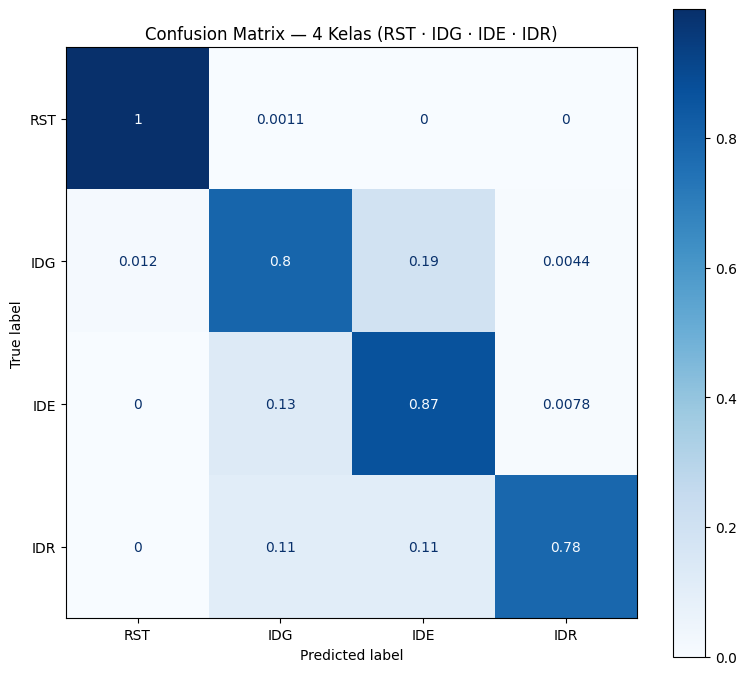

In [10]:
# ============================================================
# CELL 8 — IMBALANCE HANDLING + ENSEMBLE TUNING  (UPDATED v6)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                              classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

N_ITER_SEARCH = 40
SEARCH_CV     = 5
EVAL_REPEATS  = 3

print(f"Target 4 kelas: {TARGET_LABELS}")

# ─── 1. Tambah derived features ──────────────────────────────────────────────
enriched_tables = {}
derived_cols    = None
for ident, df in feature_tables.items():
    enriched_tables[ident], derived_cols = add_derived_features(df)

ALL_COLS_WITH_PLV = (
    [c for c in (ALL_FEATURE_COLUMNS + CONNECTIVITY_COLS)
     if c in list(enriched_tables.values())[0].columns]
    + derived_cols
)
print(f"Fitur derived  : {len(derived_cols)}")
print(f"Total fitur    : {len(ALL_COLS_WITH_PLV)}")

# ─── 2. Hyperparameter tuning ────────────────────────────────────────────────
tune_df   = enriched_tables[BEST_CONFIG_ID]
tune_cols = [c for c in ALL_COLS_WITH_PLV if c in tune_df.columns]
X_tune    = tune_df[tune_cols].fillna(0).values
y_tune    = tune_df["label"].values
g_tune    = tune_df["group_id"].values

tune_cv = StratifiedKFold(n_splits=SEARCH_CV, shuffle=True, random_state=RANDOM_STATE)
print(f"\nTuning {N_ITER_SEARCH} iterasi | {len(np.unique(g_tune))} subjek | "
      f"StratifiedKFold(k={SEARCH_CV})")

param_dist = {
    "select__k":                    [96, 128, 160, 200, min(250, len(tune_cols))],
    "ensemble__svm__C":             [1, 5, 10, 20, 50],
    "ensemble__svm__gamma":         ["scale", "auto", 0.01, 0.001],
    "ensemble__rf__n_estimators":   [200, 300, 500],
    "ensemble__rf__max_depth":      [10, 20, None],
    "ensemble__knn__n_neighbors":   [3, 5, 7, 9],
    "ensemble__knn__weights":       ["distance", "uniform"],
    "ensemble__xgb__n_estimators":  [100, 200, 300],
    "ensemble__xgb__max_depth":     [4, 6, 8],
    "ensemble__xgb__learning_rate": [0.05, 0.1, 0.2],
}

base_pipeline = make_ensemble(10, "scale", 300, 6, 5, "distance",
                               128, len(tune_cols),
                               xgb_n=200, xgb_depth=6, xgb_lr=0.1)

# Update adasyn strategy to 'auto' to avoid ValueError if classes are balanced
base_pipeline.set_params(adasyn__sampling_strategy='auto')

search = RandomizedSearchCV(
    base_pipeline, param_distributions=param_dist,
    n_iter=N_ITER_SEARCH, cv=tune_cv,
    scoring="balanced_accuracy", random_state=RANDOM_STATE,
    n_jobs=-1, refit=False, verbose=0,
)
search.fit(X_tune, y_tune)
FINAL_PARAMS = search.best_params_
print("Best params   :", FINAL_PARAMS)
print(f"CV tuning score: {search.best_score_:.4f}\n")

# ─── 3. Evaluasi akhir ───────────────────────────────────────────────────────
comparison_rows = []
for ident, df in enriched_tables.items():
    cols   = [c for c in ALL_COLS_WITH_PLV if c in df.columns]
    X      = df[cols].fillna(0).values
    y      = df["label"].values
    groups = df["group_id"].values

    pipe = make_ensemble(
        svc_C    = FINAL_PARAMS["ensemble__svm__C"],
        svc_gamma= FINAL_PARAMS["ensemble__svm__gamma"],
        rf_n     = FINAL_PARAMS["ensemble__rf__n_estimators"],
        rf_depth = FINAL_PARAMS["ensemble__rf__max_depth"],
        knn_k    = FINAL_PARAMS["ensemble__knn__n_neighbors"],
        knn_w    = FINAL_PARAMS["ensemble__knn__weights"],
        select_k = FINAL_PARAMS["select__k"],
        n_features_available = len(cols),
        xgb_n    = FINAL_PARAMS["ensemble__xgb__n_estimators"],
        xgb_depth= FINAL_PARAMS["ensemble__xgb__max_depth"],
        xgb_lr   = FINAL_PARAMS["ensemble__xgb__learning_rate"],
    )
    pipe.set_params(adasyn__sampling_strategy='auto')

    scores, all_pred, all_true = [], [], []
    for tr, te in cv_splits(y, groups, n_splits=5, n_repeats=EVAL_REPEATS):
        # Robust fit: if ADASYN fails because data is too balanced, fall back to no oversampling
        try:
            pipe.fit(X[tr], y[tr])
        except ValueError:
            temp_pipe = Pipeline(pipe.steps[1:]) # Skip ADASYN
            temp_pipe.fit(X[tr], y[tr])
            pipe = temp_pipe

        pred = pipe.predict(X[te])
        scores.append(balanced_accuracy_score(y[te], pred))
        all_pred.extend(pred)
        all_true.extend(y[te])

    comparison_rows.append({
        "config_id":    ident,
        "n_features":   len(cols),
        "mean_bal_acc": np.mean(scores),
        "std_bal_acc":  np.std(scores),
        "macro_f1":     f1_score(all_true, all_pred, average="macro", zero_division=0),
    })
    print(f"{ident[:55]:55s} → bal_acc={np.mean(scores):.4f} ± {np.std(scores):.4f}")

comparison_df = (pd.DataFrame(comparison_rows)
                   .sort_values("mean_bal_acc", ascending=False)
                   .reset_index(drop=True))
display(comparison_df)

FINAL_CONFIG_ID  = comparison_df.loc[0, "config_id"]
FINAL_COLS       = [c for c in ALL_COLS_WITH_PLV
                    if c in enriched_tables[FINAL_CONFIG_ID].columns]
final_feature_df = enriched_tables[FINAL_CONFIG_ID].copy()

# ─── 4. Laporan detail ────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"FINAL CONFIG  : {FINAL_CONFIG_ID}")
print(f"Target kelas  : {TARGET_LABELS}")
print(f"Total fitur   : {len(FINAL_COLS)}")

X_eval = final_feature_df[FINAL_COLS].fillna(0).values
y_eval = final_feature_df["label"].values
g_eval = final_feature_df["group_id"].values

eval_pipe = make_ensemble(
    FINAL_PARAMS["ensemble__svm__C"], FINAL_PARAMS["ensemble__svm__gamma"],
    FINAL_PARAMS["ensemble__rf__n_estimators"], FINAL_PARAMS["ensemble__rf__max_depth"],
    FINAL_PARAMS["ensemble__knn__n_neighbors"], FINAL_PARAMS["ensemble__knn__weights"],
    FINAL_PARAMS["select__k"], len(FINAL_COLS),
    FINAL_PARAMS["ensemble__xgb__n_estimators"],
    FINAL_PARAMS["ensemble__xgb__max_depth"],
    FINAL_PARAMS["ensemble__xgb__learning_rate"],
)
eval_pipe.set_params(adasyn__sampling_strategy='auto')

all_pred, all_true = [], []
for tr, te in cv_splits(y_eval, g_eval, n_splits=5, n_repeats=EVAL_REPEATS):
    eval_pipe.fit(X_eval[tr], y_eval[tr])
    all_pred.extend(eval_pipe.predict(X_eval[te]))
    all_true.extend(y_eval[te])

print("\nClassification Report (4 kelas: RST · IDG · IDE · IDR):")
print(classification_report(all_true, all_pred, labels=TARGET_LABELS, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    all_true, all_pred, labels=TARGET_LABELS,
    normalize="true", cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — 4 Kelas (RST · IDG · IDE · IDR)")
plt.tight_layout()
plt.show()

EVALUASI INDIVIDUAL BASE CLASSIFIER
Dataset       : epoch_2.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v6_primary_boost_plv_dwt_125hz
Jumlah epoch  : 934
Jumlah fitur  : 480  (select_k=250)
Distribusi    : {'RST': 300, 'IDG': 300, 'IDE': 300, 'IDR': 34}

  [RandomForest] ...   cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.6959
  [SVM RBF] ...   cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.6992
  [KNN] ...   cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.7000
  [XGBoost] ...   cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.7166
  [Ensemble (SVM+RF+KNN+XGB)] ...   cv_splits fallback: 1 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.8613


,Classifier,Accuracy,Balanced Accuracy,Std Bal Acc,Macro F1
4,Ensemble (SVM+RF+KNN+XGB),0.883298,0.861310,0.047357,0.870903
3,XGBoost,0.799429,0.716627,0.046315,0.736991
2,KNN,0.619914,0.699960,0.018853,0.571332
1,SVM RBF,0.690221,0.699206,0.036353,0.639613
0,RandomForest,0.809422,0.695873,0.045417,0.725988


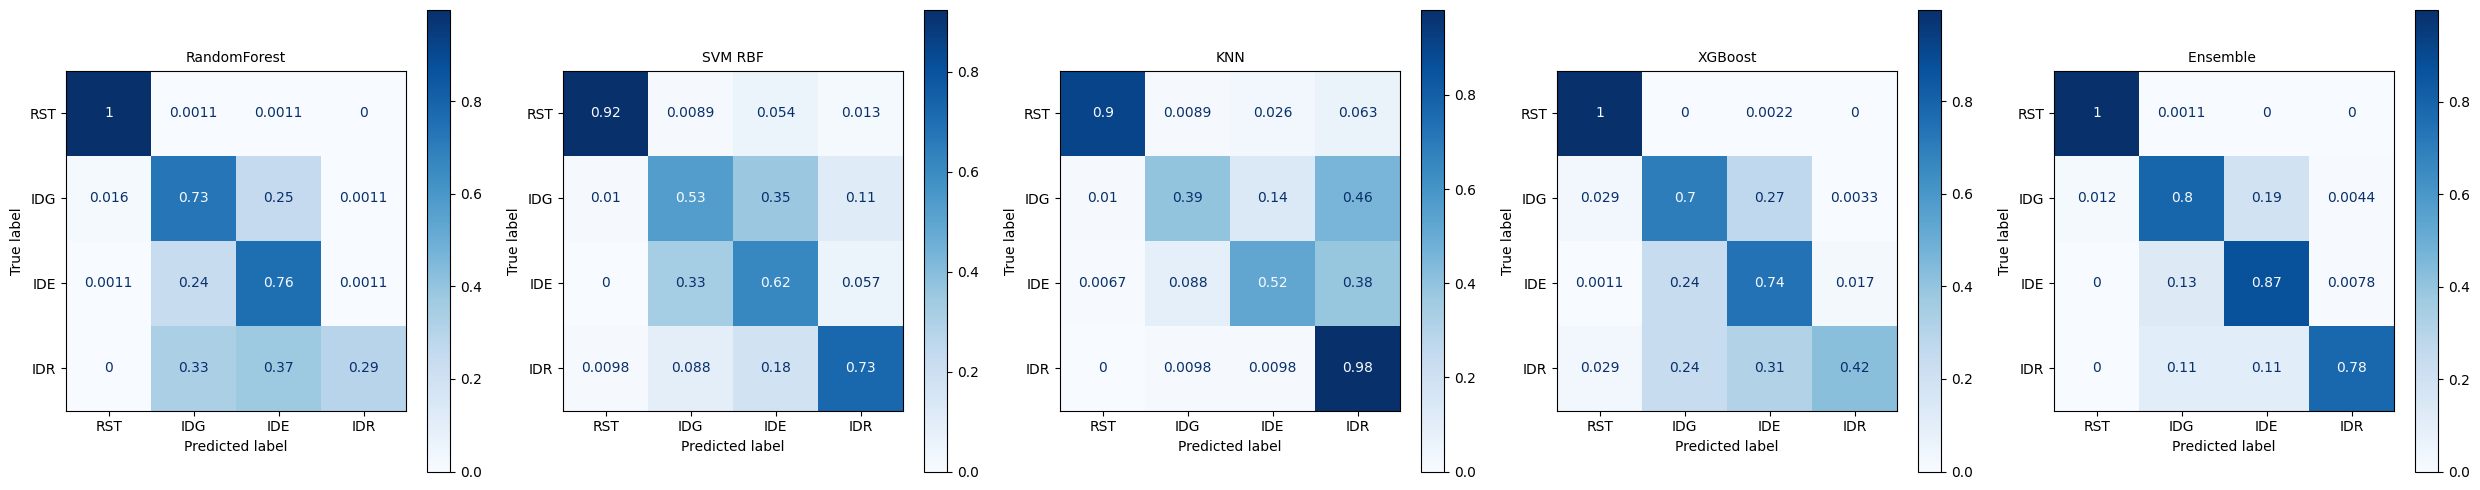

Tabel disimpan: /content/drive/MyDrive/Creativity-Dataset/output/individual_classifier_comparison_secondary.csv


In [11]:
# ============================================================
# EVALUASI PER CLASSIFIER INDIVIDUAL
# ============================================================

from imblearn.over_sampling import ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("EVALUASI INDIVIDUAL BASE CLASSIFIER")
print("=" * 70)

# ── Ambil data dari config terbaik ────
_X   = final_feature_df[FINAL_COLS].fillna(0).values
_y   = final_feature_df["label"].values
_grp = final_feature_df["group_id"].values

_k   = min(FINAL_PARAMS["select__k"], len(FINAL_COLS))

# Tambahkan LabelEncoder untuk XGBoost
le = LabelEncoder()
le.fit(TARGET_LABELS)

print(f"Dataset       : {FINAL_CONFIG_ID}")
print(f"Jumlah epoch  : {len(_y)}")
print(f"Jumlah fitur  : {len(FINAL_COLS)}  (select_k={_k})")
print(f"Distribusi    : { {lb: int(((_y==lb).sum())) for lb in TARGET_LABELS} }")
print()

# ── Helper: buat pipeline individual ──────────
def _make_individual(clf, k):
    return ImbPipeline([
        ("adasyn",  ADASYN(sampling_strategy="auto", random_state=RANDOM_STATE, n_neighbors=5)),
        ("select",  SelectKBest(score_func=f_classif, k=min(k, len(FINAL_COLS)))),
        ("clf",     clf),
    ])

def _make_individual_safe(clf, k):
    return ImbPipeline([
        ("adasyn",  RandomOverSampler(sampling_strategy="auto", random_state=RANDOM_STATE)),
        ("select",  SelectKBest(score_func=f_classif, k=min(k, len(FINAL_COLS)))),
        ("clf",     clf),
    ])

# ── Definisi classifier individual ──────────────────────
INDIVIDUAL_CLASSIFIERS = {
    "RandomForest": RandomForestClassifier(
        n_estimators = FINAL_PARAMS["ensemble__rf__n_estimators"],
        max_depth    = FINAL_PARAMS["ensemble__rf__max_depth"],
        class_weight = "balanced_subsample",
        random_state = RANDOM_STATE, n_jobs = -1,
    ),
    "SVM RBF": SVC(
        C            = FINAL_PARAMS["ensemble__svm__C"],
        gamma        = FINAL_PARAMS["ensemble__svm__gamma"],
        kernel       = "rbf", class_weight = "balanced",
        probability  = False, random_state = RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors  = FINAL_PARAMS["ensemble__knn__n_neighbors"],
        weights      = FINAL_PARAMS["ensemble__knn__weights"], n_jobs = -1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators   = FINAL_PARAMS["ensemble__xgb__n_estimators"],
        max_depth      = FINAL_PARAMS["ensemble__xgb__max_depth"],
        learning_rate  = FINAL_PARAMS["ensemble__xgb__learning_rate"],
        use_label_encoder = False, eval_metric = "mlogloss",
        random_state   = RANDOM_STATE, n_jobs = -1, verbosity = 0,
    ),
    "Ensemble (SVM+RF+KNN+XGB)": make_ensemble(
        svc_C = FINAL_PARAMS["ensemble__svm__C"], svc_gamma = FINAL_PARAMS["ensemble__svm__gamma"],
        rf_n = FINAL_PARAMS["ensemble__rf__n_estimators"], rf_depth = FINAL_PARAMS["ensemble__rf__max_depth"],
        knn_k = FINAL_PARAMS["ensemble__knn__n_neighbors"], knn_w = FINAL_PARAMS["ensemble__knn__weights"],
        select_k = _k, n_features_available = len(FINAL_COLS),
        xgb_n = FINAL_PARAMS["ensemble__xgb__n_estimators"], xgb_depth = FINAL_PARAMS["ensemble__xgb__max_depth"], xgb_lr = FINAL_PARAMS["ensemble__xgb__learning_rate"],
    ),
}

# ── Loop evaluasi ────────────────────────────────
indiv_results = []
indiv_preds   = {}

for clf_name, clf_obj in INDIVIDUAL_CLASSIFIERS.items():
    print(f"  [{clf_name}] ...", end=" ", flush=True)
    fold_bal = []; yt_all = []; yp_all = []
    is_ensemble = clf_name.startswith("Ensemble")
    is_xgb = clf_name == "XGBoost"

    for tr, te in cv_splits(_y, _grp, n_splits=5, n_repeats=EVAL_REPEATS):
        X_tr, X_te = _X[tr], _X[te]
        y_tr = le.transform(_y[tr]) if is_xgb else _y[tr]
        y_te = le.transform(_y[te]) if is_xgb else _y[te]

        pipe = clf_obj if is_ensemble else _make_individual(clf_obj, _k)
        if is_ensemble: pipe.set_params(adasyn__sampling_strategy="auto")

        try:
            pipe.fit(X_tr, y_tr)
        except Exception:
            pipe = (ImbPipeline(pipe.steps[1:]) if is_ensemble else _make_individual_safe(clf_obj, _k))
            pipe.fit(X_tr, y_tr)

        pred = pipe.predict(X_te)
        if is_xgb:
            y_te_str = le.inverse_transform(y_te)
            pred_str = le.inverse_transform(pred)
            fold_bal.append(balanced_accuracy_score(y_te_str, pred_str))
            yt_all.extend(y_te_str); yp_all.extend(pred_str)
        else:
            fold_bal.append(balanced_accuracy_score(y_te, pred))
            yt_all.extend(y_te); yp_all.extend(pred)

    yt_all, yp_all = np.array(yt_all), np.array(yp_all)
    row = {"Classifier": clf_name, "Accuracy": accuracy_score(yt_all, yp_all), "Balanced Accuracy": np.mean(fold_bal), "Std Bal Acc": np.std(fold_bal), "Macro F1": f1_score(yt_all, yp_all, average="macro", zero_division=0)}
    indiv_results.append(row); indiv_preds[clf_name] = (yt_all, yp_all)
    print(f"Bal.Acc={row['Balanced Accuracy']:.4f}")

# ── Visualization & CSV ──────────────────────
indiv_df = pd.DataFrame(indiv_results).sort_values("Balanced Accuracy", ascending=False)
display(indiv_df)

n_clf = len(indiv_preds)
fig, axes = plt.subplots(1, n_clf, figsize=(5 * n_clf, 5))
if n_clf == 1: axes = [axes]
for ax, (clf_name, (yt, yp)) in zip(axes, indiv_preds.items()):
    ConfusionMatrixDisplay.from_predictions(yt, yp, labels=TARGET_LABELS, normalize="true", cmap="Blues", ax=ax)
    ax.set_title(clf_name.split("(")[0], fontsize=10)
plt.tight_layout(); plt.show()

out_path = OUTPUT_DIR / "individual_classifier_comparison_secondary.csv"
indiv_df.to_csv(out_path, index=False)
print(f"Tabel disimpan: {out_path}")

In [14]:
# ============================================================
# CELL 9 — FIT FINAL MODEL
# ============================================================
final_training_df = (
    final_feature_df[final_feature_df["source"] == "secondary"].copy()
    if DATASET_MODE == "external_validation"
    else final_feature_df.copy()
)
X_final = final_training_df[FINAL_COLS].fillna(0).values
y_final = final_training_df["label"].values

final_pipeline = make_ensemble(
    FINAL_PARAMS["ensemble__svm__C"],
    FINAL_PARAMS["ensemble__svm__gamma"],
    FINAL_PARAMS["ensemble__rf__n_estimators"],
    FINAL_PARAMS["ensemble__rf__max_depth"],
    FINAL_PARAMS["ensemble__knn__n_neighbors"],
    FINAL_PARAMS["ensemble__knn__weights"],
    FINAL_PARAMS["select__k"],
    len(FINAL_COLS),
)

print(f"Melatih model final pada konfigurasi: {FINAL_CONFIG_ID} ...")
final_pipeline.fit(X_final, y_final)

run_label = "_".join(sorted(final_training_df["source"].unique()))

model_bundle = {
    "model":           final_pipeline,
    "dataset_mode":    DATASET_MODE,
    "run_label":       run_label,
    "final_config_id": FINAL_CONFIG_ID,
    "final_params":    FINAL_PARAMS,
    "feature_columns": FINAL_COLS,
    "channels":        CANONICAL_CHANNELS,
    "sampling_rate":   FS_TARGET,
    "target_labels":   TARGET_LABELS,   # 4 kelas: RST, IDG, IDE, IDR
}

model_path = OUTPUT_DIR / f"ensemble_model__{run_label}.joblib"
joblib.dump(model_bundle, model_path)
print("MODEL TERSIMPAN:", model_path)

Melatih model final pada konfigurasi: epoch_2.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v6_primary_boost_plv_dwt_125hz ...
MODEL TERSIMPAN: /content/drive/MyDrive/Creativity-Dataset/output/ensemble_model__secondary.joblib


In [15]:
# ============================================================
# CELL 10 (FIXED) — EXTERNAL VALIDATION (SECONDARY -> PRIMARY)
# ============================================================
if DATASET_MODE != "external_validation":
    print("Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.")
else:
    ext_df = enriched_tables[FINAL_CONFIG_ID]
    ext_df = ext_df[ext_df["source"] == "primary"].copy()
    if ext_df.empty:
        raise ValueError("Dataset primer kosong. Pastikan file tersedia di folder Primary-raw.")
    X_ext, y_ext = ext_df[FINAL_COLS].values, ext_df["label"].astype(str).values
    ext_preds = final_pipeline.predict(X_ext)   # <- FIX: dulu salah pakai final_model
    print("EXTERNAL VALIDATION: Train (Concordia) -> Test (OpenBCI)")
    print(f"Accuracy: {accuracy_score(y_ext, ext_preds):.4f} | "
          f"BalAcc: {balanced_accuracy_score(y_ext, ext_preds):.4f} | "
          f"Macro-F1: {f1_score(y_ext, ext_preds, average='macro', zero_division=0):.4f}")
    print("\nCLASSIFICATION REPORT:\n", classification_report(y_ext, ext_preds, labels=LABELS, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(y_ext, ext_preds, labels=LABELS, normalize="true", values_format=".2f", ax=ax)
    ax.set_title("External Validation: Train Secondary -> Test Primary")
    plt.tight_layout(); plt.show()
    ext_res_df = ext_df[["source", "subject_id", "record_id", "label", "epoch_start"]].copy()
    ext_res_df["predicted_label"] = ext_preds
    ext_res_df.to_csv(OUTPUT_DIR / "external_validation_predictions.csv", index=False)

Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.


delta            theta            alpha            beta             \
       mean  std count  mean  std count  mean  std count mean  std count   
label                                                                      
IDE     0.0  0.0   300   0.0  0.0   300   0.0  0.0   300  0.0  0.0   300   
IDG     0.0  0.0   300   0.0  0.0   300   0.0  0.0   300  0.0  0.0   300   
IDR     0.0  0.0    34   0.0  0.0    34   0.0  0.0    34  0.0  0.0    34   
RST     0.0  0.0   300   0.0  0.0   300   0.0  0.0   300  0.0  0.0   300   

      gamma             
       mean  std count  
label                   
IDE     0.0  0.0   300  
IDG     0.0  0.0   300  
IDR     0.0  0.0    34  
RST     0.0  0.0   300


Uji Normalitas Shapiro-Wilk:


,band,condition,n,shapiro_w,shapiro_p,normal_at_alpha_0_05
0,delta,IDG,300,1.0,1.0,True
1,delta,IDE,300,1.0,1.0,True
2,delta,IDR,34,1.0,1.0,True
3,delta,RST,300,1.0,1.0,True
4,theta,IDG,300,1.0,1.0,True
5,theta,IDE,300,1.0,1.0,True
6,theta,IDR,34,1.0,1.0,True
7,theta,RST,300,1.0,1.0,True
8,alpha,IDG,300,1.0,1.0,True
9,alpha,IDE,300,1.0,1.0,True



Uji Statistik Pairwise dengan Koreksi Bonferroni:


,band,condition_a,condition_b,n_a,n_b,test,statistic,p_uncorrected,effect_metric,effect_size,mean_a,mean_b,bonferroni_family_size,p_bonferroni,significant_bonferroni
12,alpha,IDG,IDE,300,300,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
13,alpha,IDG,IDR,300,34,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
14,alpha,IDG,RST,300,300,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
15,alpha,IDE,IDR,300,34,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
16,alpha,IDE,RST,300,300,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
17,alpha,IDR,RST,34,300,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
18,beta,IDG,IDE,300,300,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
19,beta,IDG,IDR,300,34,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
20,beta,IDG,RST,300,300,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False
21,beta,IDE,IDR,300,34,Welch t-test,NaN,NaN,Cohen's d,0.0,0.0,0.0,0,NaN,False


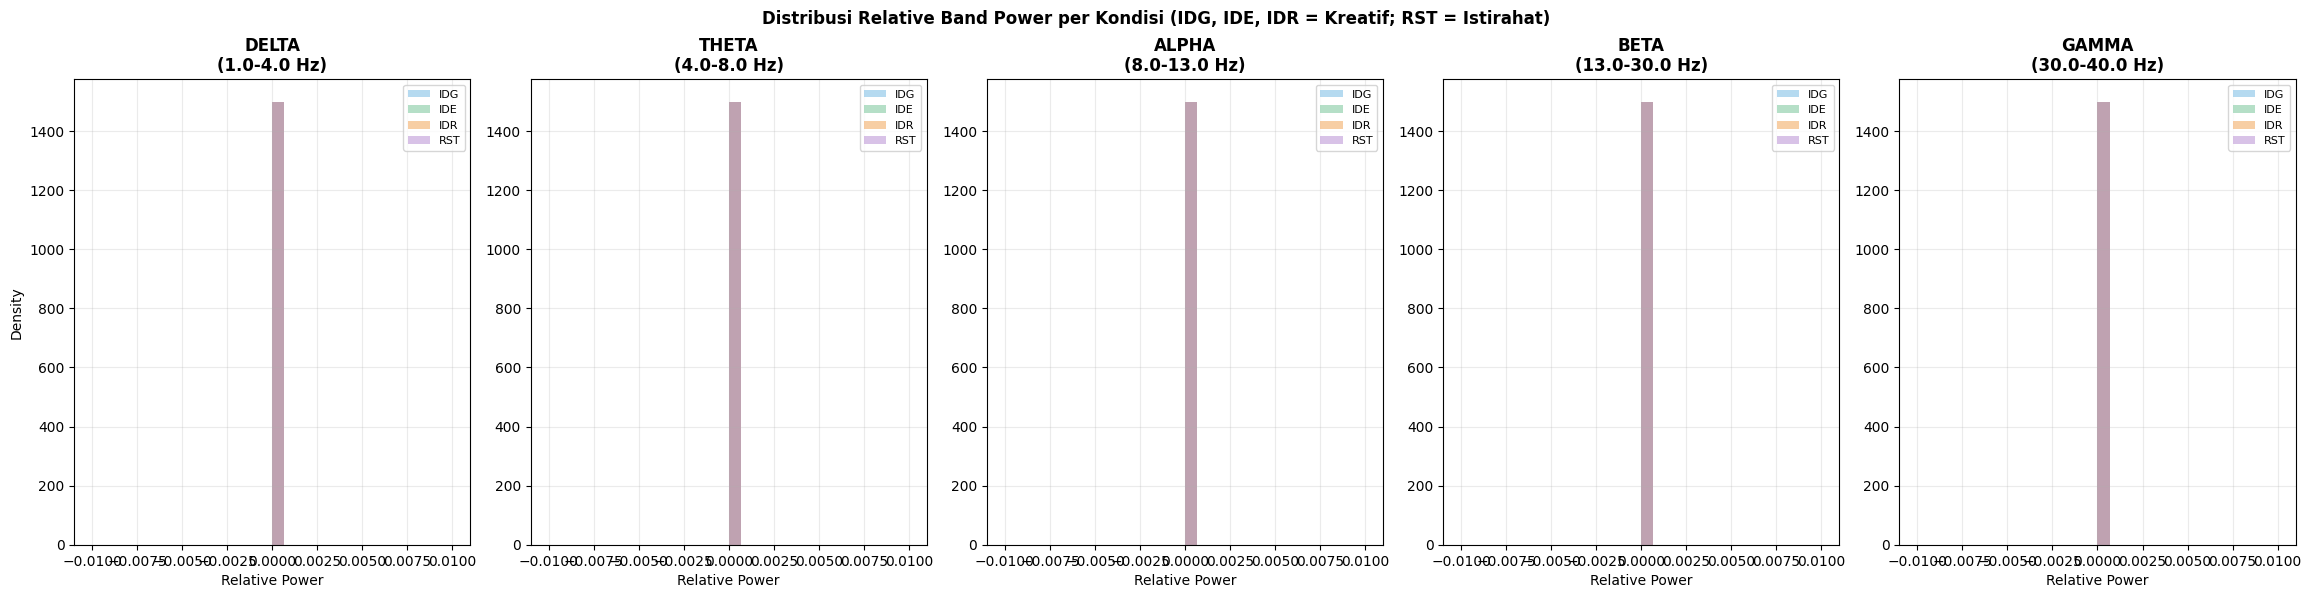


Output tersimpan di: /content/drive/MyDrive/Creativity-Dataset/output
Catatan: karena epoch overlap, hasil inferensial bersifat eksploratif untuk dataset/subjek yang sedang dianalisis.


In [13]:
# ============================================================
# CELL 11 - VISUALISASI RELATIVE BAND POWER & UJI STATISTIK
# ============================================================
# Menggunakan fitur PSD Welch yang sudah diekstrak pada Cell 5.
# Relative power tiap band dirata-ratakan dari 16 kanal per epoch.

from itertools import combinations
from scipy.stats import mannwhitneyu, shapiro, ttest_ind

STAT_ALPHA = 0.05
STAT_LABEL_ORDER = [
    label for label in ["IDG", "IDE", "IDR", "RST"]
    if label in final_feature_df["label"].unique()
]
STAT_OUTPUT_SUFFIX = str(DATASET_MODE).lower()

STAT_COLORS = {
    "IDG": "#79BCE5",
    "IDE": "#78C69A",
    "IDR": "#F2A65A",
    "RST": "#B990D4",
}

def build_relative_band_power_table(feature_df):
    meta_cols = [
        "source", "subject_id", "record_id",
        "label", "epoch_start", "epoch_size"
    ]
    out = feature_df[[c for c in meta_cols if c in feature_df.columns]].copy()

    for band in FREQUENCY_BANDS:
        cols = [
            f"{channel}__spectral__{band}"
            for channel in CANONICAL_CHANNELS
        ]

        missing = [col for col in cols if col not in feature_df.columns]
        if missing:
            raise ValueError(
                f"Fitur spectral untuk band {band} tidak lengkap. "
                "Pastikan ADD_SPECTRAL_FEATURES = True."
            )

        out[band] = (
            feature_df[cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean(axis=1)
        )

    return out


def cohen_d_independent(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2 or len(y) < 2:
        return np.nan

    pooled_sd = np.sqrt(
        (
            (len(x) - 1) * np.var(x, ddof=1)
            + (len(y) - 1) * np.var(y, ddof=1)
        )
        / (len(x) + len(y) - 2)
    )

    return float((np.mean(x) - np.mean(y)) / pooled_sd) if pooled_sd > 0 else 0.0


def rank_biserial_from_u(u_statistic, n_x, n_y):
    if not n_x or not n_y:
        return np.nan

    # Positif = condition_a cenderung lebih tinggi dari condition_b
    return float((2 * u_statistic / (n_x * n_y)) - 1)


def run_relative_band_statistics(band_df, alpha=STAT_ALPHA):
    normality_rows = []
    test_rows = []
    bands = list(FREQUENCY_BANDS)

    # Uji normalitas Shapiro-Wilk
    for band in bands:
        for label in STAT_LABEL_ORDER:
            values = (
                band_df.loc[band_df["label"] == label, band]
                .dropna()
                .to_numpy(float)
            )

            if len(values) < 3:
                statistic, p_value = np.nan, np.nan
            else:
                shapiro_values = values if len(values) <= 5000 else values[:5000]
                statistic, p_value = shapiro(shapiro_values)

            normality_rows.append({
                "band": band,
                "condition": label,
                "n": len(values),
                "shapiro_w": statistic,
                "shapiro_p": p_value,
                "normal_at_alpha_0_05": bool(
                    pd.notna(p_value) and p_value > alpha
                ),
            })

    normality_df = pd.DataFrame(normality_rows)

    # Uji statistik setiap pasangan kondisi
    for band in bands:
        for condition_a, condition_b in combinations(STAT_LABEL_ORDER, 2):
            values_a = (
                band_df.loc[band_df["label"] == condition_a, band]
                .dropna()
                .to_numpy(float)
            )
            values_b = (
                band_df.loc[band_df["label"] == condition_b, band]
                .dropna()
                .to_numpy(float)
            )

            normal_a = normality_df.query(
                "band == @band and condition == @condition_a"
            )["normal_at_alpha_0_05"].iloc[0]

            normal_b = normality_df.query(
                "band == @band and condition == @condition_b"
            )["normal_at_alpha_0_05"].iloc[0]

            if len(values_a) < 2 or len(values_b) < 2:
                test_name = "Insufficient data"
                statistic = np.nan
                p_value = np.nan
                effect_name = ""
                effect_size = np.nan

            elif normal_a and normal_b:
                statistic, p_value = ttest_ind(
                    values_a,
                    values_b,
                    equal_var=False,
                    nan_policy="omit",
                )
                test_name = "Welch t-test"
                effect_name = "Cohen's d"
                effect_size = cohen_d_independent(values_a, values_b)

            else:
                statistic, p_value = mannwhitneyu(
                    values_a,
                    values_b,
                    alternative="two-sided",
                )
                test_name = "Mann-Whitney U"
                effect_name = "Rank-biserial r"
                effect_size = rank_biserial_from_u(
                    statistic,
                    len(values_a),
                    len(values_b),
                )

            test_rows.append({
                "band": band,
                "condition_a": condition_a,
                "condition_b": condition_b,
                "n_a": len(values_a),
                "n_b": len(values_b),
                "test": test_name,
                "statistic": statistic,
                "p_uncorrected": p_value,
                "effect_metric": effect_name,
                "effect_size": effect_size,
                "mean_a": np.mean(values_a) if len(values_a) else np.nan,
                "mean_b": np.mean(values_b) if len(values_b) else np.nan,
            })

    tests_df = pd.DataFrame(test_rows)

    valid_tests = tests_df["p_uncorrected"].notna().sum()
    tests_df["bonferroni_family_size"] = valid_tests
    tests_df["p_bonferroni"] = np.minimum(
        tests_df["p_uncorrected"] * valid_tests,
        1.0,
    )
    tests_df["significant_bonferroni"] = (
        tests_df["p_bonferroni"] < alpha
    )

    return normality_df, tests_df


def plot_relative_band_power_distributions(band_df):
    fig, axes = plt.subplots(
        1,
        len(FREQUENCY_BANDS),
        figsize=(23, 5.6),
        constrained_layout=True,
    )

    for ax, (band, (low_hz, high_hz)) in zip(
        axes,
        FREQUENCY_BANDS.items(),
    ):
        values_by_condition = [
            band_df.loc[
                band_df["label"] == label,
                band
            ].dropna().to_numpy(float)
            for label in STAT_LABEL_ORDER
        ]

        nonempty_values = [
            values for values in values_by_condition if len(values)
        ]
        finite_values = (
            np.concatenate(nonempty_values)
            if nonempty_values
            else np.array([])
        )

        if len(finite_values) and finite_values.max() > finite_values.min():
            bins = np.linspace(
                finite_values.min(),
                finite_values.max(),
                31,
            )
        elif len(finite_values):
            centre = finite_values[0]
            bins = np.linspace(centre - 0.01, centre + 0.01, 31)
        else:
            bins = 30

        for label, values in zip(
            STAT_LABEL_ORDER,
            values_by_condition,
        ):
            if len(values):
                ax.hist(
                    values,
                    bins=bins,
                    density=True,
                    alpha=0.55,
                    color=STAT_COLORS.get(label),
                    label=label,
                    edgecolor="none",
                )

        ax.set_title(
            f"{band.upper()}\n({low_hz:.1f}-{high_hz:.1f} Hz)",
            fontweight="bold",
        )
        ax.set_xlabel("Relative Power")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, frameon=True)

        if band == list(FREQUENCY_BANDS)[0]:
            ax.set_ylabel("Density")

    fig.suptitle(
        "Distribusi Relative Band Power per Kondisi (IDG, IDE, IDR = Kreatif; RST = Istirahat)",
        fontweight="bold",
        y=1.04,
    )

    return fig


# ============================================================
# JALANKAN ANALISIS
# ============================================================

relative_band_power_df = build_relative_band_power_table(final_feature_df)

normality_results_df, statistical_results_df = run_relative_band_statistics(
    relative_band_power_df
)

display(
    relative_band_power_df
    .groupby("label")[list(FREQUENCY_BANDS)]
    .agg(["mean", "std", "count"])
    .round(4)
)

print("\nUji Normalitas Shapiro-Wilk:")
display(normality_results_df)

print("\nUji Statistik Pairwise dengan Koreksi Bonferroni:")
display(
    statistical_results_df
    .sort_values(["p_bonferroni", "band"])
)

fig = plot_relative_band_power_distributions(relative_band_power_df)

figure_path = OUTPUT_DIR / (
    f"relative_band_power_distribution__{STAT_OUTPUT_SUFFIX}.png"
)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

relative_band_power_df.to_csv(
    OUTPUT_DIR / (
        f"relative_band_power_epoch_features__{STAT_OUTPUT_SUFFIX}.csv"
    ),
    index=False,
)

normality_results_df.to_csv(
    OUTPUT_DIR / (
        f"normality_test_relative_band_power__{STAT_OUTPUT_SUFFIX}.csv"
    ),
    index=False,
)

statistical_results_df.to_csv(
    OUTPUT_DIR / (
        f"pairwise_statistics_relative_band_power__{STAT_OUTPUT_SUFFIX}.csv"
    ),
    index=False,
)

print(f"\nOutput tersimpan di: {OUTPUT_DIR}")
print(
    "Catatan: karena epoch overlap, hasil inferensial bersifat eksploratif "
    "untuk dataset/subjek yang sedang dianalisis."
)